In [3]:
#Imports + display helpers
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap="inferno"):
    plt.figure(figsize=(5,4))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

def plot_curve(y, title="", xlabel="", ylabel="", labels=None):
    plt.figure(figsize=(6,4))
    if y.ndim == 1:
        plt.plot(y)
    else:
        for i in range(y.shape[0]):
            plt.plot(y[i], label=None if labels is None else labels[i])
        if labels is not None:
            plt.legend()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

In [4]:
#Import the pipeline (module name = pipelinefinalproject)
import pipelinefinalproject as pf

print("Loaded:", pf.__file__)

Loaded: C:\Users\pkwki\project_nextgen\pipelinefinalproject.py


data4d: (64, 64, 128, 128) mask_true: (64, 64)


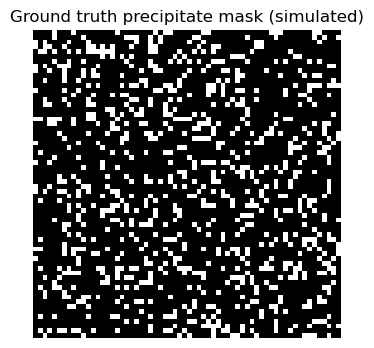

In [5]:
#Make simulated 4D-STEM datacube + ground truth mask
#This simulator makes:matrix: broad diffuse ring, precipitate: sharper ring peaks + mild anisotropy + noise
def simulate_pattern(P=128, kind="matrix", rng=None):
    if rng is None:
        rng = np.random.default_rng()

    yy, xx = np.indices((P, P))
    cy, cx = (P-1)/2, (P-1)/2
    r = np.sqrt((yy-cy)**2 + (xx-cx)**2)
    rmax = r.max()

    pat = np.zeros((P,P), np.float32)

    # base diffuse background
    pat += 0.02 * np.exp(-(r/(0.9*rmax))**2)

    if kind == "matrix":
        # broad ring
        r0 = 0.35*rmax
        w  = 0.06*rmax
        pat += np.exp(-0.5*((r-r0)/w)**2)

    elif kind == "precip":
        # sharper peaks/rings
        for frac, amp in [(0.22, 1.0), (0.35, 0.8), (0.50, 0.6)]:
            r0 = frac*rmax
            w  = 0.018*rmax
            pat += amp*np.exp(-0.5*((r-r0)/w)**2)

        # add mild anisotropy (simulate oriented spots/texture)
        ang = np.arctan2(yy-cy, xx-cx)
        pat *= (1.0 + 0.25*np.cos(6*ang))

    else:
        raise ValueError("kind must be 'matrix' or 'precip'")

    # add noise
    pat += 0.05 * rng.standard_normal((P,P)).astype(np.float32)
    pat[pat < 0] = 0
    return pat

def simulate_4dstem(Ny=64, Nx=64, P=128, precip_frac=0.2, seed=42):
    rng = np.random.default_rng(seed)
    mask = rng.random((Ny, Nx)) < precip_frac
    data = np.zeros((Ny, Nx, P, P), np.float32)
    for j in range(Ny):
        for i in range(Nx):
            data[j,i] = simulate_pattern(P=P, kind="precip" if mask[j,i] else "matrix", rng=rng)
    return data, mask

Ny, Nx, P = 64, 64, 128
data4d, mask_true = simulate_4dstem(Ny=Ny, Nx=Nx, P=P, precip_frac=0.20, seed=42)

print("data4d:", data4d.shape, "mask_true:", mask_true.shape)
show(mask_true, "Ground truth precipitate mask (simulated)", cmap="gray")

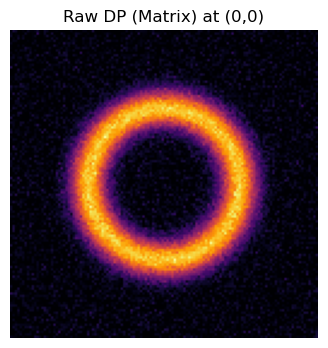

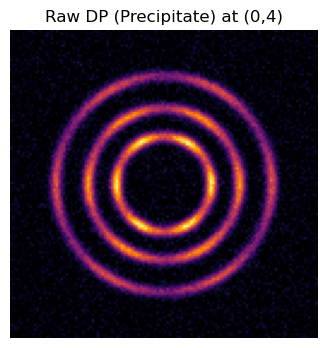

In [6]:
#Pick example pixels + show raw diffraction patterns
py, px = np.argwhere(mask_true)[0]      # precipitate pixel
my, mx = np.argwhere(~mask_true)[0]     # matrix pixel

dpP_raw = data4d[py, px]
dpM_raw = data4d[my, mx]

show(dpM_raw, f"Raw DP (Matrix) at ({my},{mx})")
show(dpP_raw, f"Raw DP (Precipitate) at ({py},{px})")

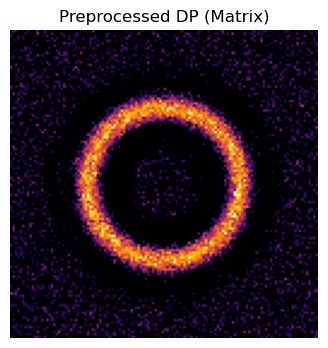

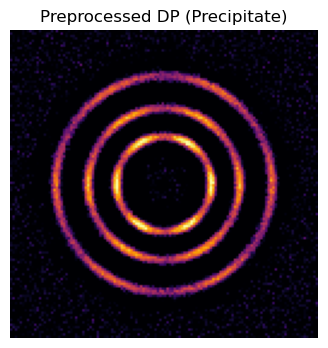

In [7]:
#Step: Preprocess pattern + show result
pre_kwargs = dict(
    blur_sigma=5.0,
    log_compress=True,
    winsor_q=0.999,
    center_mask_frac=0.03,
    normalize="sum",
)

dpM = pf.preprocess_pattern(dpM_raw, **pre_kwargs)
dpP = pf.preprocess_pattern(dpP_raw, **pre_kwargs)

show(dpM, "Preprocessed DP (Matrix)")
show(dpP, "Preprocessed DP (Precipitate)")

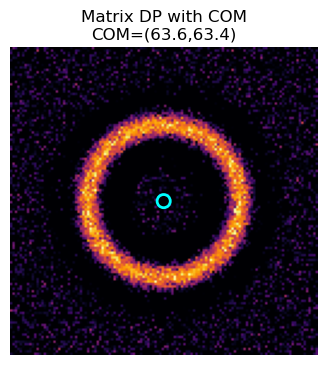

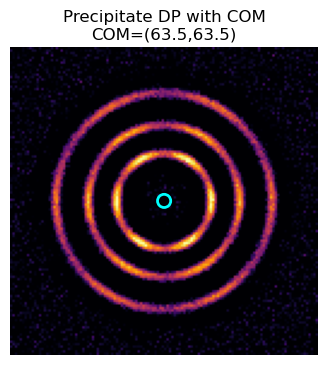

In [8]:
#Step: COM centering (visualize COM point)
def show_com(dp, title):
    cy, cx = pf.estimate_center_of_mass(dp)
    plt.figure(figsize=(5,4))
    plt.imshow(dp, cmap="inferno")
    plt.scatter([cx], [cy], s=90, facecolors="none", edgecolors="cyan", linewidths=2)
    plt.title(f"{title}\nCOM=({cy:.1f},{cx:.1f})")
    plt.axis("off")
    plt.show()
    return (cy, cx)

comM = show_com(dpM, "Matrix DP with COM")
comP = show_com(dpP, "Precipitate DP with COM")

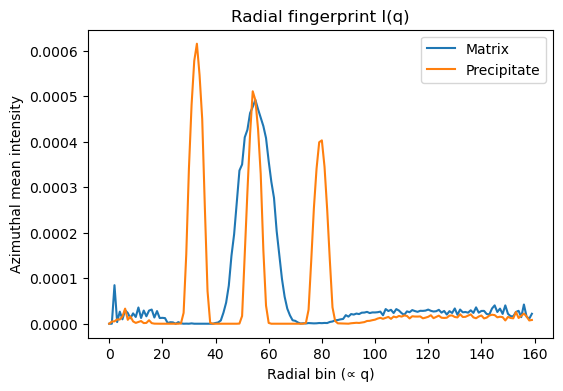

In [9]:
#Step: Radial fingerprint I(q) + plot
radial_bins = 160

rM = pf.radial_profile(dpM, center=comM, radial_bins=radial_bins, r_min_frac=0.02, r_max_frac=0.98)
rP = pf.radial_profile(dpP, center=comP, radial_bins=radial_bins, r_min_frac=0.02, r_max_frac=0.98)

plot_curve(np.vstack([rM, rP]),
           title="Radial fingerprint I(q)",
           xlabel="Radial bin (∝ q)",
           ylabel="Azimuthal mean intensity",
           labels=["Matrix", "Precipitate"])

In [10]:
#Step: Radial peak features (numbers that can be cited)
f_rM = pf.radial_peak_features(rM, k_peaks=3, peak_rel_height=0.15)
f_rP = pf.radial_peak_features(rP, k_peaks=3, peak_rel_height=0.15)

print("Radial peak features (Matrix):")
for k,v in f_rM.items():
    print(f"  {k:15s} {v:.4g}")

print("\nRadial peak features (Precipitate):")
for k,v in f_rP.items():
    print(f"  {k:15s} {v:.4g}")

Radial peak features (Matrix):
  rad_total       0.009378
  rad_max         0.0004917
  rad_var         1.305e-08
  rad_npeaks      2
  rad_prom_mean   0.000288
  rad_width_mean  7.86
  rad_peakpos_1   0.3438
  rad_peakht_1    0.0004917
  rad_peakpos_2   0.0125
  rad_peakht_2    8.469e-05
  rad_peakpos_3   0
  rad_peakht_3    0

Radial peak features (Precipitate):
  rad_total       0.009758
  rad_max         0.0006152
  rad_var         1.814e-08
  rad_npeaks      3
  rad_prom_mean   0.0005096
  rad_width_mean  5.829
  rad_peakpos_1   0.2062
  rad_peakht_1    0.0006152
  rad_peakpos_2   0.3375
  rad_peakht_2    0.0005108
  rad_peakpos_3   0.5
  rad_peakht_3    0.0004028


In [11]:
#Step: Virtual detector features (BF/DF/ADF/HAADF)
vdM = pf.virtual_detector_features(dpM, center=comM)
vdP = pf.virtual_detector_features(dpP, center=comP)

print("Virtual detector features (Matrix):", vdM)
print("Virtual detector features (Precipitate):", vdP)

Virtual detector features (Matrix): {'I_bf': 0.002922401297837496, 'I_df': 0.7653747200965881, 'I_adf': 0.1566048264503479, 'I_haadf': 0.06289775669574738, 'df_bf_ratio': 261.8992540145144, 'highangle_frac': 0.22221365539684546}
Virtual detector features (Precipitate): {'I_bf': 0.0018341344548389316, 'I_df': 0.894191324710846, 'I_adf': 0.06531791388988495, 'I_haadf': 0.036360785365104675, 'df_bf_ratio': 487.5276847148284, 'highangle_frac': 0.10191267461071928}


In [12]:
#Step: Angular / anisotropy features
angM = pf.angular_features(dpM, center=comM, n_sectors=12)
angP = pf.angular_features(dpP, center=comP, n_sectors=12)

print("Angular features (Matrix):", angM)
print("Angular features (Precipitate):", angP)

Angular features (Matrix): {'anis_ratio': 0.16825993359088898, 'ang_entropy': np.float64(0.9993496828197179), 'anis_std': 0.06491850316524506}
Angular features (Precipitate): {'anis_ratio': 0.19539718329906464, 'ang_entropy': np.float64(0.9997923808679801), 'anis_std': 0.08347161114215851}


In [13]:
#Step: Bragginess (2D peakiness) features
brM = pf.bragginess_features_2d(dpM, center=comM, peak_q=0.999)
brP = pf.bragginess_features_2d(dpP, center=comP, peak_q=0.999)

print("Bragginess features (Matrix):", brM)
print("Bragginess features (Precipitate):", brP)

Bragginess features (Matrix): {'bragg_count': 17.0, 'bragg_frac': 0.010780733439958978, 'bragg_density': 0.0010793650793650793}
Bragginess features (Precipitate): {'bragg_count': 17.0, 'bragg_frac': 0.01304464667168933, 'bragg_density': 0.001079639273466277}


In [14]:
#Step: COM shift features
csM = pf.com_shift_features(dpM)
csP = pf.com_shift_features(dpP)

print("COM shift features (Matrix):", csM)
print("COM shift features (Precipitate):", csP)

COM shift features (Matrix): {'com_shift': 0.008525634491186828, 'com_sin': -0.5806174779108066, 'com_cos': -0.814176482308654}
COM shift features (Precipitate): {'com_shift': 0.007749263453768811, 'com_sin': -0.7653406796279256, 'com_cos': -0.6436253911295491}


Clustering 4096 patterns into 2 clusters using gmm with features ['radial', 'detectors', 'angular', 'bragginess', 'com']
Detrending: subtract Gaussian background per feature (sigma=8.0)
PCA: kept 29 components for 98.0% variance target


C:\Users\pkwki\anaconda3\envs\matsci465project\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


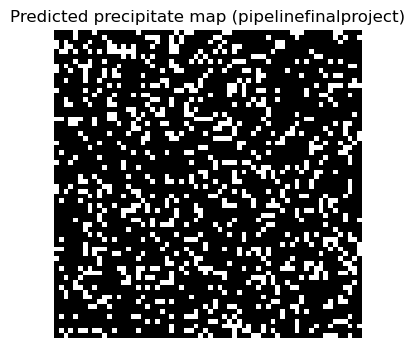

In [15]:
#Step: Run full robust pipeline (detect_phases_multi) + show output
res = pf.detect_phases_multi(
    data4d,
    n_clusters=2,
    method="gmm",              # try "kmeans" if you want
    radial_bins=160,
    feature_groups=["radial","detectors","angular","bragginess","com"],
    preprocess_kwargs=pre_kwargs,
    use_pca=True,
    pca_var=0.98,
    detrend=True,
    detrend_sigma=8.0,
    map_precipitate=True,
    size_prior=0.7,
    spatial_refine=False,
    verbose=True
)

labels_map = res["labels_map"]
show(labels_map, "Predicted precipitate map (pipelinefinalproject)", cmap="gray")

Pixel accuracy: 1.000
IoU (Jaccard): 1.000


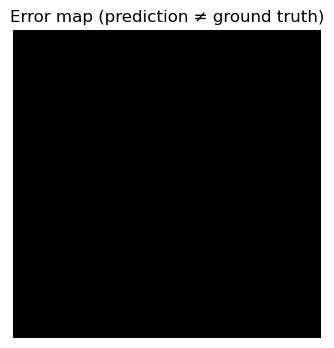

In [16]:
#Step: Evaluate vs ground truth + show error map
pred = labels_map.astype(bool)
gt = mask_true.astype(bool)

acc = (pred == gt).mean()
iou = (pred & gt).sum() / ((pred | gt).sum() + 1e-12)

print(f"Pixel accuracy: {acc:.3f}")
print(f"IoU (Jaccard): {iou:.3f}")

err = (pred != gt)
show(err, "Error map (prediction ≠ ground truth)", cmap="gray")

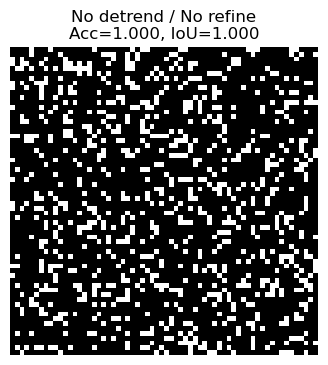

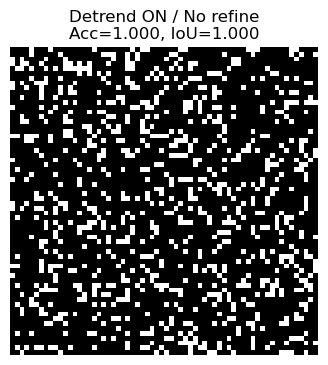

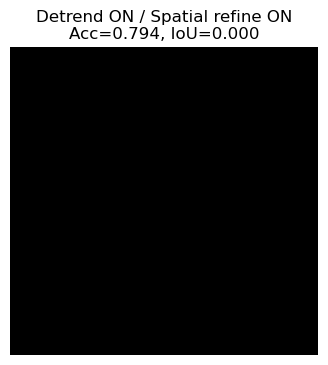

In [17]:
#Step: Show effect of robustness options (detrend / spatial refine)
def run_variant(detrend, spatial_refine):
    out = pf.detect_phases_multi(
        data4d,
        n_clusters=2,
        method="gmm",
        radial_bins=160,
        preprocess_kwargs=pre_kwargs,
        detrend=detrend,
        detrend_sigma=8.0,
        spatial_refine=spatial_refine,
        majority_size=3,
        min_island=10,
        verbose=False
    )["labels_map"].astype(bool)

    acc = (out == gt).mean()
    iou = (out & gt).sum() / ((out | gt).sum() + 1e-12)
    return out.astype(int), acc, iou

m0, a0, i0 = run_variant(detrend=False, spatial_refine=False)
m1, a1, i1 = run_variant(detrend=True,  spatial_refine=False)
m2, a2, i2 = run_variant(detrend=True,  spatial_refine=True)

show(m0, f"No detrend / No refine\nAcc={a0:.3f}, IoU={i0:.3f}", cmap="gray")
show(m1, f"Detrend ON / No refine\nAcc={a1:.3f}, IoU={i1:.3f}", cmap="gray")
show(m2, f"Detrend ON / Spatial refine ON\nAcc={a2:.3f}, IoU={i2:.3f}", cmap="gray")

In [19]:
res = pf.detect_phases_multi(
    data4d,
    n_clusters=2,
    method="gmm",  # or "kmeans"
    radial_bins=160,
    feature_groups=["radial", "detectors", "angular", "bragginess", "com"],
    preprocess_kwargs=dict(
        blur_sigma=5.0,
        log_compress=True,
        winsor_q=0.999,
        center_mask_frac=0.03,
        normalize="sum",
    ),
    use_pca=True,
    pca_var=0.98,
    detrend=True,
    detrend_sigma=8.0,
    map_precipitate=True,
    size_prior=0.7,
    spatial_refine=False,
    verbose=True
)

Clustering 4096 patterns into 2 clusters using gmm with features ['radial', 'detectors', 'angular', 'bragginess', 'com']
Detrending: subtract Gaussian background per feature (sigma=8.0)
PCA: kept 29 components for 98.0% variance target


In [20]:
import numpy as np
import matplotlib.pyplot as plt

def show_feature_map(res, feature_name, Ny, Nx, cmap="viridis", normalize=True):
    rawX = res["raw_features"]
    names = list(res["feature_names"])

    if feature_name not in names:
        print(f"{feature_name} not found. Try one of:\n", names[:30], "...")
        return

    idx = names.index(feature_name)
    fmap = rawX[:, idx].reshape(Ny, Nx)

    if normalize:
        lo, hi = np.percentile(fmap, [1, 99])
        fmap = np.clip(fmap, lo, hi)
        fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-12)

    plt.figure(figsize=(5,4))
    plt.imshow(fmap, cmap=cmap)
    plt.colorbar()
    plt.title(f"Feature map: {feature_name}")
    plt.axis("off")
    plt.show()

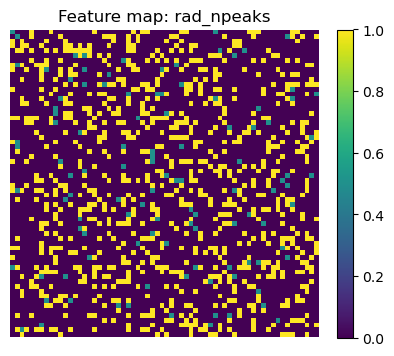

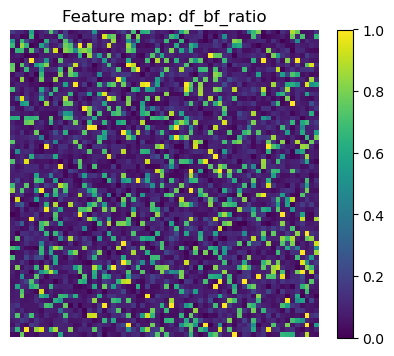

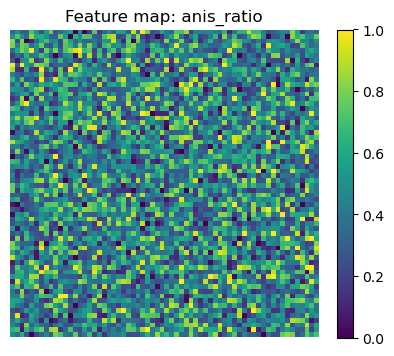

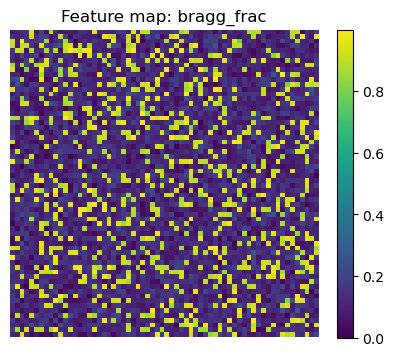

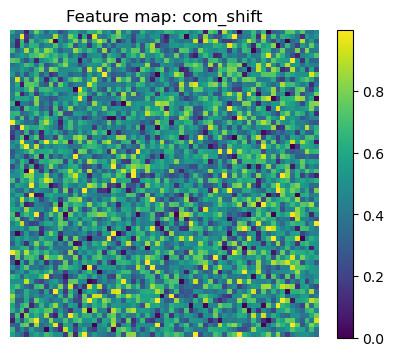

In [21]:
Ny, Nx = data4d.shape[:2]

for f in ["rad_npeaks", "df_bf_ratio", "anis_ratio", "bragg_frac", "com_shift"]:
    show_feature_map(res, f, Ny, Nx)

In [22]:
fmap = res["raw_features"][:, list(res["feature_names"]).index("bragg_frac")].reshape(Ny, Nx)

corr = np.corrcoef(fmap.ravel(), mask_true.ravel())[0,1]
print("Correlation (bragg_frac vs ground truth):", corr)

Correlation (bragg_frac vs ground truth): 0.9888208118030183


In [32]:
import pandas as pd
import numpy as np

def features_to_df(res, mask_true=None, pred_map=None):
    Ny, Nx = res["labels_map"].shape
    names = list(res["feature_names"])
    rawX = res["raw_features"]

    df = pd.DataFrame(rawX, columns=names)
    yy, xx = np.indices((Ny, Nx))
    df.insert(0, "y", yy.ravel())
    df.insert(1, "x", xx.ravel())

    # predicted (from pipeline)
    df["pred"] = res["labels_map"].ravel().astype(int)

    # ground truth if provided
    if mask_true is not None:
        df["gt"] = mask_true.ravel().astype(int)

    return df

df_feat = features_to_df(res, mask_true=mask_true)
df_feat.head()

,y,x,rad_prof_0,rad_prof_1,rad_prof_2,rad_prof_3,rad_prof_4,rad_prof_5,rad_prof_6,rad_prof_7,...,ang_entropy,anis_std,bragg_count,bragg_frac,bragg_density,com_shift,com_sin,com_cos,pred,gt
0,0,0,0.0,0.000027,0.000012,0.000013,0.000031,0.000013,0.000003,0.000000e+00,...,0.999350,0.064919,17.0,0.010781,0.001079,0.008526,-0.580617,-0.814176,0,0
1,0,1,0.0,0.000032,0.000017,0.000024,0.000018,0.000016,0.000004,4.735849e-07,...,0.999617,0.073740,17.0,0.010849,0.001080,0.007243,-0.631830,-0.775107,0,0
2,0,2,0.0,0.000021,0.000033,0.000013,0.000012,0.000012,0.000003,1.683734e-07,...,0.999517,0.068400,17.0,0.010941,0.001080,0.007486,-0.782233,-0.622986,0,0
3,0,3,0.0,0.000045,0.000021,0.000013,0.000022,0.000013,0.000003,2.097327e-07,...,0.999346,0.063107,17.0,0.010957,0.001079,0.005555,-0.672728,-0.739890,0,0
4,0,4,0.0,0.000009,0.000016,0.000006,0.000001,0.000000,0.000000,2.382735e-05,...,0.999792,0.083472,17.0,0.013045,0.001080,0.007749,-0.765341,-0.643625,1,0


In [37]:
print("mask_true shape:", mask_true.shape, "dtype:", mask_true.dtype)
print("mask_true True count:", np.sum(mask_true))
print("mask_true False count:", np.sum(~mask_true))

Ny, Nx = data4d.shape[:2]
print("data4d scan shape:", (Ny, Nx))

# check match
assert mask_true.shape == (Ny, Nx), "mask_true shape does NOT match data4d scan shape!"

mask_true shape: (64, 64) dtype: bool
mask_true True count: 0
mask_true False count: 4096
data4d scan shape: (64, 64)


In [38]:
Ny, Nx, P = 64, 64, 128
data4d, mask_true = simulate_4dstem(Ny=Ny, Nx=Nx, P=P, precip_frac=0.20, seed=42)

print("mask_true True count:", int(mask_true.sum()), "out of", mask_true.size)
print("mask_true dtype:", mask_true.dtype)
print("mask_true unique:", np.unique(mask_true))

mask_true True count: 844 out of 4096
mask_true dtype: bool
mask_true unique: [False  True]


In [39]:
print("mask_true sum right before histogram:", mask_true.sum())
print("res labels_map sum:", res["labels_map"].sum())

mask_true sum right before histogram: 844
res labels_map sum: 844


In [40]:
import numpy as np
import matplotlib.pyplot as plt

def plot_feature_histogram(res, feature_name, mask_true, Ny, Nx,
                           bins=60, clip_percentile=(1,99),
                           density=False):

    names = list(res["feature_names"])
    rawX = res["raw_features"]

    if feature_name not in names:
        print(f"{feature_name} not found.")
        return

    idx = names.index(feature_name)
    values = rawX[:, idx].reshape(Ny, Nx)

    # clip extreme values for nicer visualization
    lo, hi = np.percentile(values, clip_percentile)
    values = np.clip(values, lo, hi)

    matrix_vals = values[~mask_true]
    precip_vals = values[mask_true]

    plt.figure(figsize=(6,4))
    plt.hist(matrix_vals, bins=bins, alpha=0.6, label="Matrix", density=density)
    plt.hist(precip_vals, bins=bins, alpha=0.6, label="Precipitate", density=density)
    plt.xlabel(feature_name)
    plt.ylabel("Density" if density else "Count")
    plt.title(f"Distribution of {feature_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

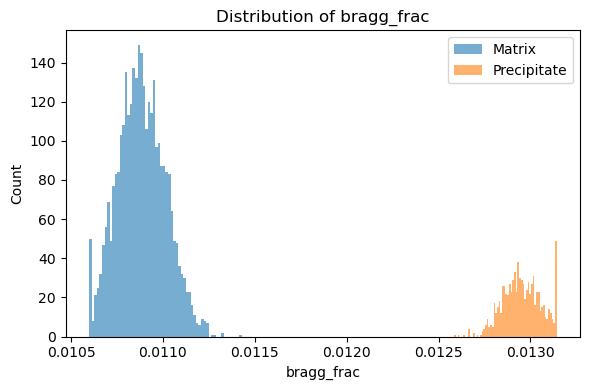

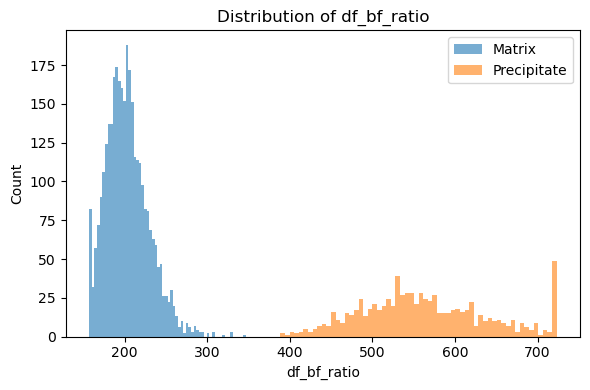

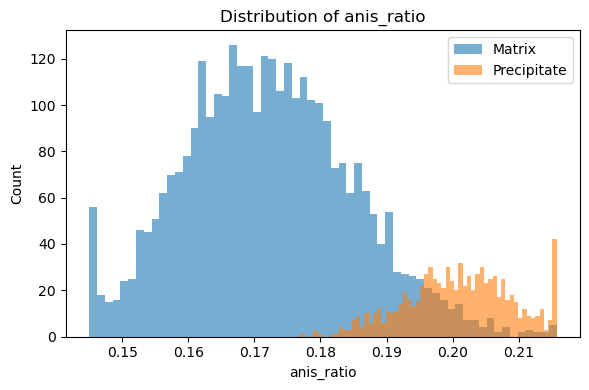

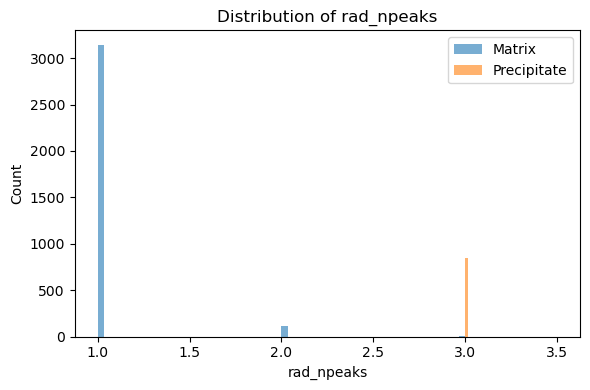

In [41]:
plot_feature_histogram(res, "bragg_frac", mask_true, Ny, Nx)
plot_feature_histogram(res, "df_bf_ratio", mask_true, Ny, Nx)
plot_feature_histogram(res, "anis_ratio", mask_true, Ny, Nx)
plot_feature_histogram(res, "rad_npeaks", mask_true, Ny, Nx)

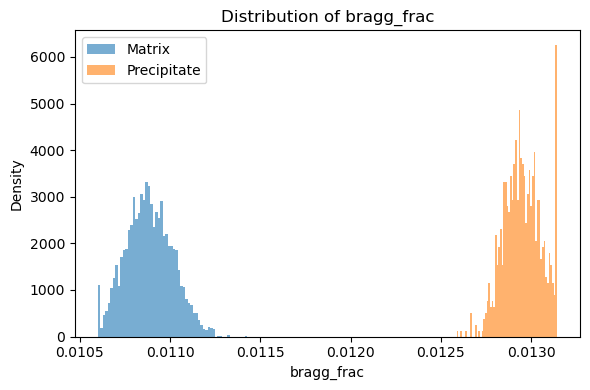

In [42]:
plot_feature_histogram(res, "bragg_frac", mask_true, Ny, Nx, density=True)

In [43]:
def plot_multiple_histograms(res, mask_true, Ny, Nx, features):
    n = len(features)
    cols = 2
    rows = (n + 1) // 2

    plt.figure(figsize=(10, 4*rows))

    for i, feature in enumerate(features):
        names = list(res["feature_names"])
        if feature not in names:
            continue

        idx = names.index(feature)
        values = res["raw_features"][:, idx].reshape(Ny, Nx)

        lo, hi = np.percentile(values, [1,99])
        values = np.clip(values, lo, hi)

        matrix_vals = values[~mask_true]
        precip_vals = values[mask_true]

        plt.subplot(rows, cols, i+1)
        plt.hist(matrix_vals, bins=60, alpha=0.6, label="Matrix")
        plt.hist(precip_vals, bins=60, alpha=0.6, label="Precipitate")
        plt.title(feature)
        plt.legend()

    plt.tight_layout()
    plt.show()

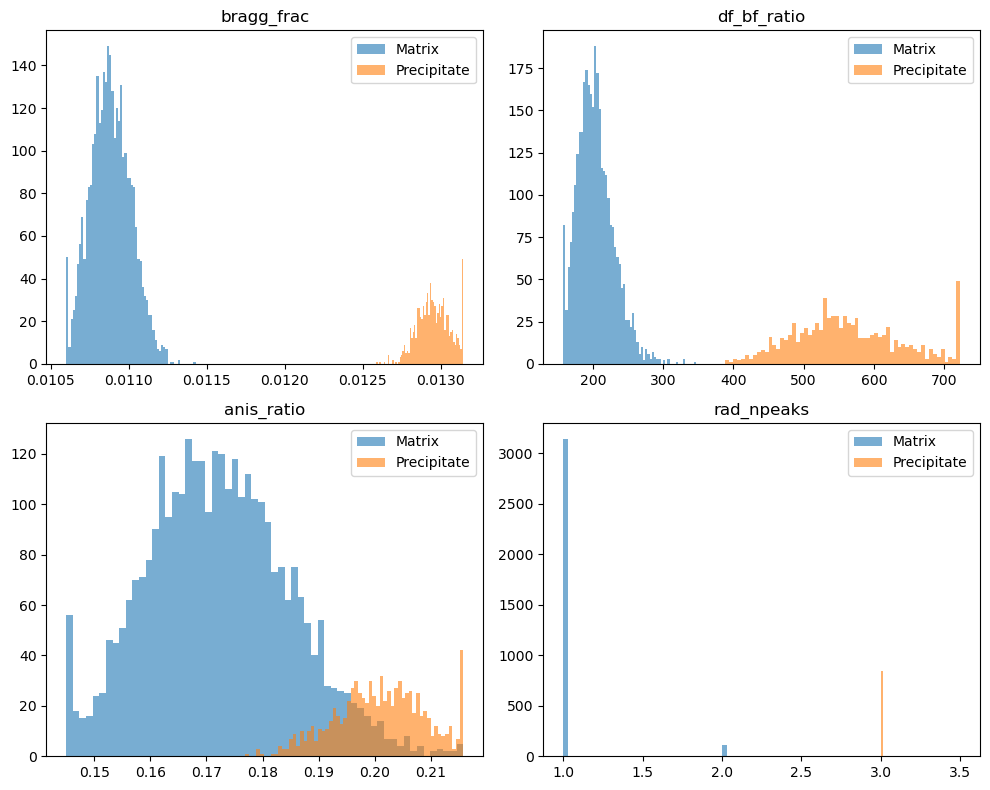

In [44]:
plot_multiple_histograms(
    res,
    mask_true,
    Ny,
    Nx,
    ["bragg_frac", "df_bf_ratio", "anis_ratio", "rad_npeaks"]
)

In [45]:
def feature_stats(res, feature_name, mask_true, Ny, Nx):
    idx = list(res["feature_names"]).index(feature_name)
    v = res["raw_features"][:, idx].reshape(Ny, Nx)

    print(feature_name)
    print("Matrix mean:", v[~mask_true].mean())
    print("Precip mean:", v[mask_true].mean())
    print("Difference:", v[mask_true].mean() - v[~mask_true].mean())
    print()

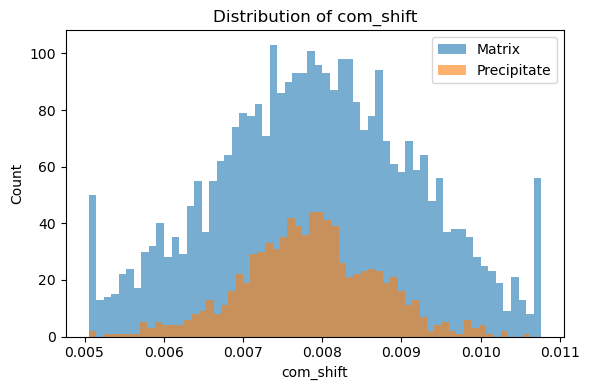

In [46]:
plot_feature_histogram(res, "com_shift", mask_true, Ny, Nx)

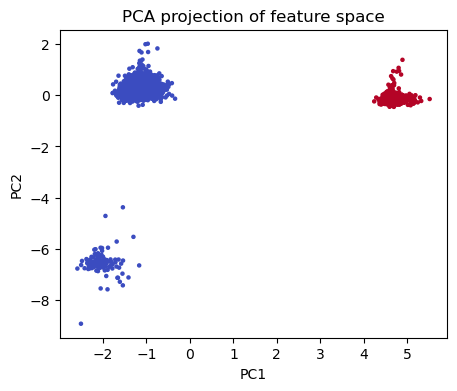

In [47]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = res["features"]

pca2 = PCA(n_components=2)
X2 = pca2.fit_transform(X)

plt.figure(figsize=(5,4))
plt.scatter(X2[:,0], X2[:,1], c=res["labels"], s=5, cmap="coolwarm")
plt.title("PCA projection of feature space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

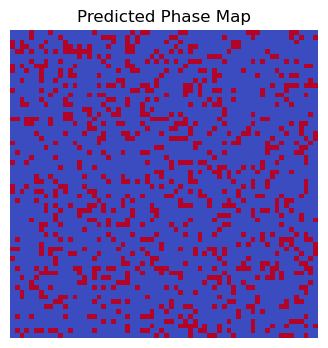

In [49]:
plt.figure(figsize=(5,4))
plt.imshow(res["labels_map"], cmap="coolwarm")
plt.title("Predicted Phase Map")
plt.axis("off")
plt.show()